In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df1 = pd.read_csv("data\\meteorological_observations_1_1_2022-11_24_2024.csv", parse_dates=["time"])
df2 = pd.read_csv("data\\meteorological_observations_11_27_2024-3_31_2026.csv", parse_dates=["time"])

df = pd.concat([df1, df2], ignore_index=True).sort_values("time").reset_index(drop=True)

# Convert Celsius to Fahrenheit
df["temp_f"] = df["temp"] * 9 / 5 + 32

print(f"Combined range: {df['time'].min()} → {df['time'].max()}")
print(f"Total rows: {len(df):,}")
df[["time", "temp", "temp_f"]].head()

Combined range: 2022-01-01 00:00:00 → 2026-03-31 23:00:00
Total rows: 37,174


,time,temp,temp_f
0,2022-01-01 00:00:00,2.0,35.60
1,2022-01-01 01:00:00,1.7,35.06
2,2022-01-01 02:00:00,1.1,33.98
3,2022-01-01 03:00:00,1.7,35.06
4,2022-01-01 04:00:00,1.7,35.06


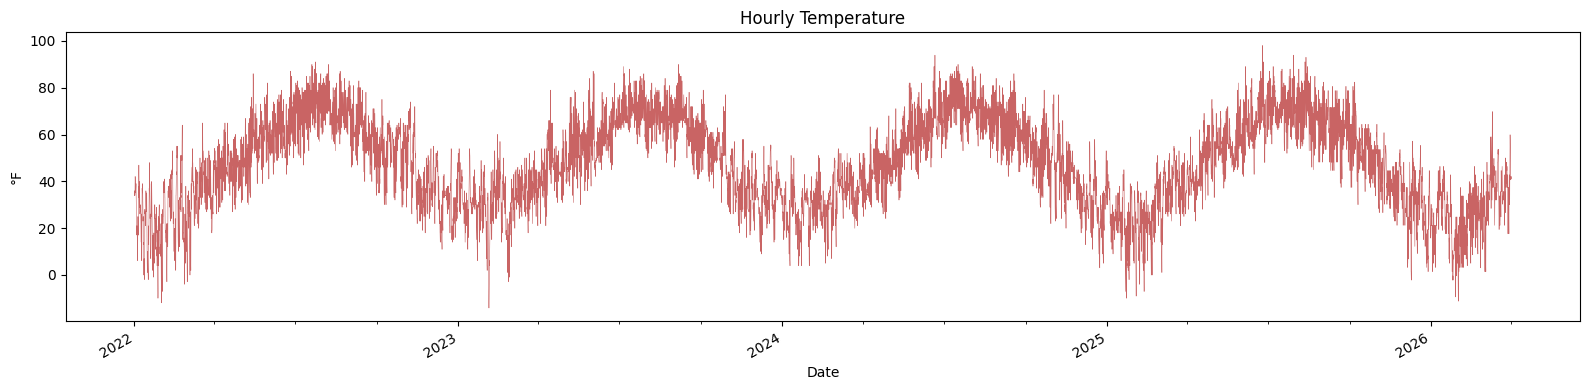

In [11]:
# Hourly
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df["time"], df["temp_f"], linewidth=0.4, color="firebrick", alpha=0.7)
ax.set_title("Hourly Temperature")
ax.set_xlabel("Date")
ax.set_ylabel("°F")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

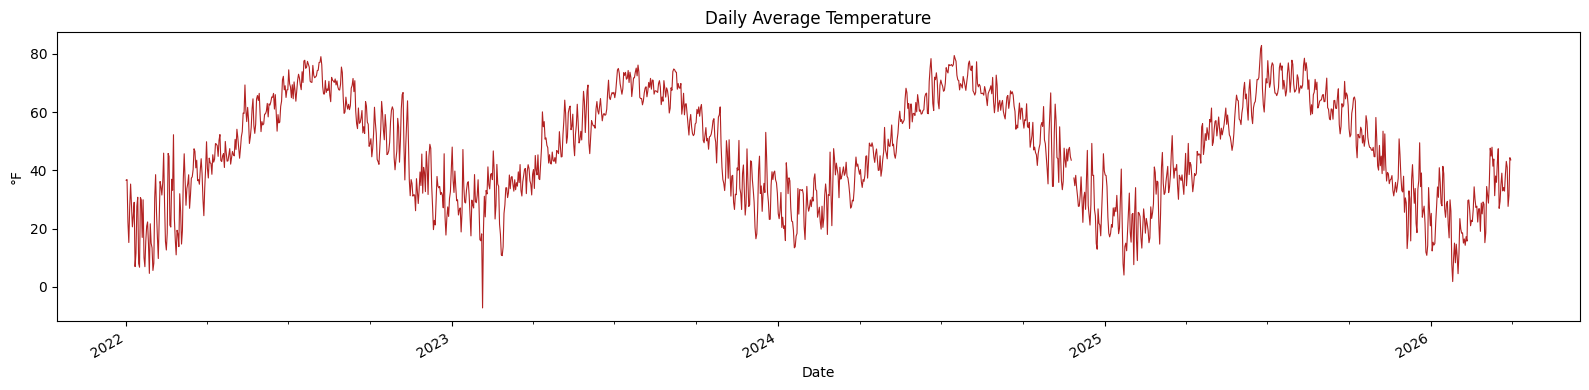

In [12]:
# Daily avg
daily = df.resample("D", on="time")["temp_f"].mean()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(daily.index, daily.values, linewidth=0.8, color="firebrick")
ax.set_title("Daily Average Temperature")
ax.set_xlabel("Date")
ax.set_ylabel("°F")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

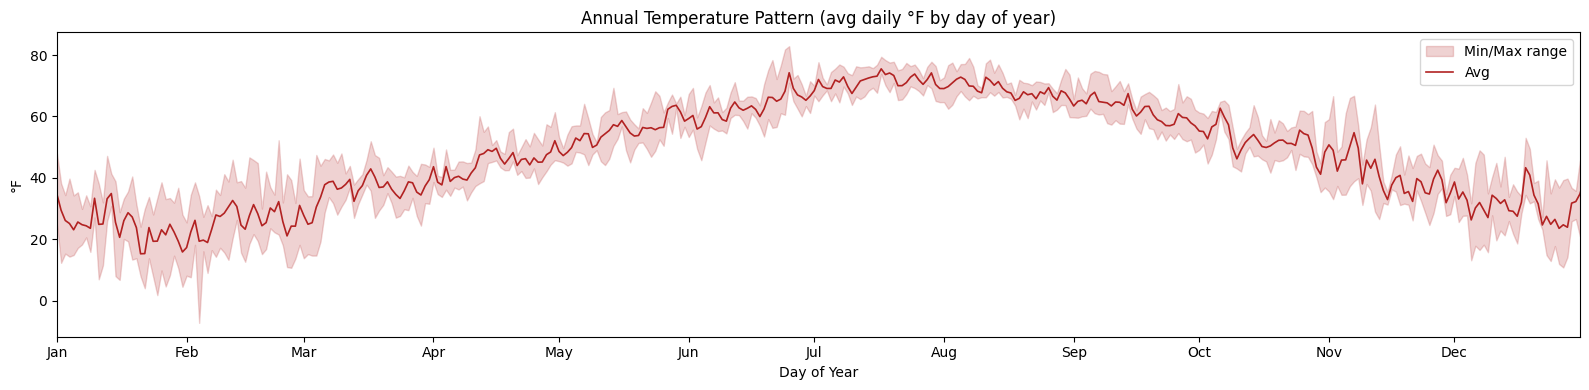

In [13]:
# Annual pattern (avg daily temp by day-of-year, across all years)
daily_doy = df.resample("D", on="time")["temp_f"].mean().reset_index()
daily_doy["doy"] = daily_doy["time"].dt.day_of_year

by_doy = daily_doy.groupby("doy")["temp_f"]
avg = by_doy.mean()
low = by_doy.min()
high = by_doy.max()

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(avg.index, low.values, high.values, color="firebrick", alpha=0.2, label="Min/Max range")
ax.plot(avg.index, avg.values, color="firebrick", linewidth=1.2, label="Avg")
ax.set_title("Annual Temperature Pattern (avg daily °F by day of year)")
ax.set_xlabel("Day of Year")
ax.set_ylabel("°F")
ax.set_xlim(1, 365)
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.legend()
plt.tight_layout()
plt.show()

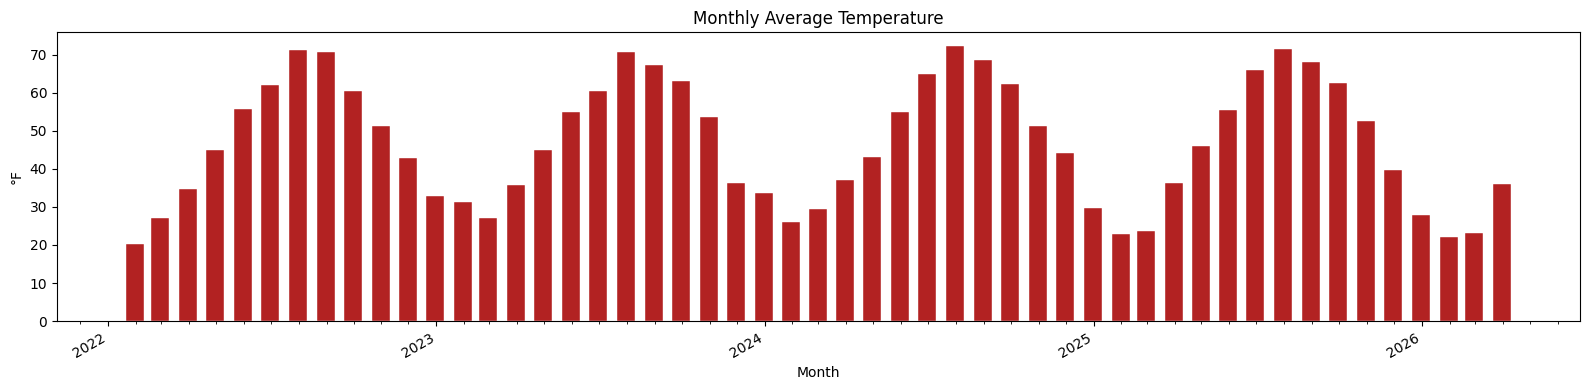

In [14]:
# Monthly avg
monthly = df.resample("ME", on="time")["temp_f"].mean()

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(monthly.index, monthly.values, width=20, color="firebrick", edgecolor="white", linewidth=0.3)
ax.set_title("Monthly Average Temperature")
ax.set_xlabel("Month")
ax.set_ylabel("°F")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

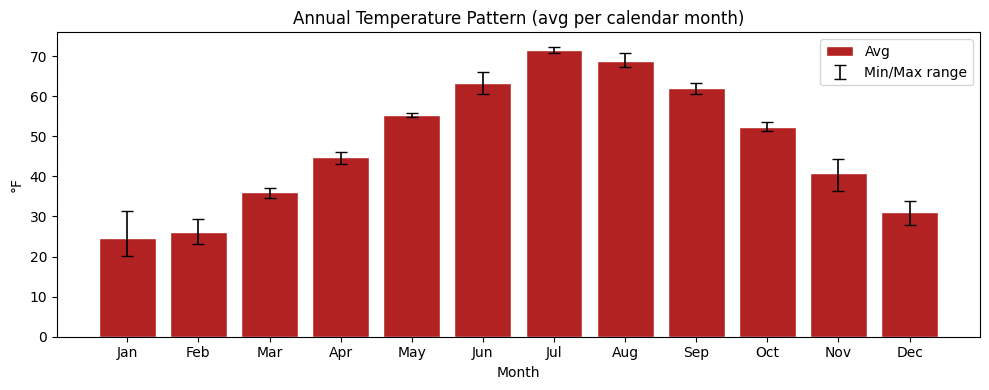

In [15]:
# Annual pattern (avg temp per calendar month, across all years)
monthly_cal = df.resample("ME", on="time")["temp_f"].mean().reset_index()
monthly_cal["month"] = monthly_cal["time"].dt.month

by_month = monthly_cal.groupby("month")["temp_f"]
avg = by_month.mean()
low = by_month.min()
high = by_month.max()

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(avg.index, avg.values, color="firebrick", edgecolor="white", label="Avg")
ax.errorbar(avg.index, avg.values,
            yerr=[avg.values - low.values, high.values - avg.values],
            fmt="none", color="black", capsize=4, linewidth=1.2, label="Min/Max range")
ax.set_title("Annual Temperature Pattern (avg per calendar month)")
ax.set_xlabel("Month")
ax.set_ylabel("°F")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend()
plt.tight_layout()
plt.show()

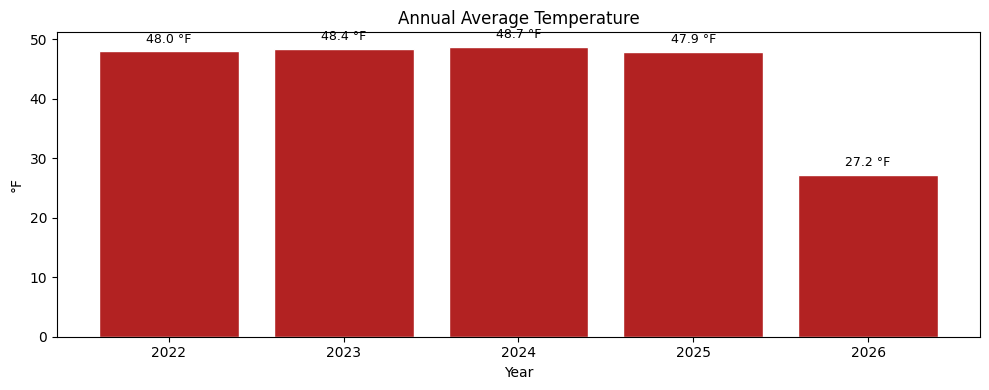

In [16]:
# Annual avg
annual = df.resample("YE", on="time")["temp_f"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(annual.index.year, annual.values, color="firebrick", edgecolor="white")
ax.bar_label(bars, fmt="%.1f °F", padding=4, fontsize=9)
ax.set_title("Annual Average Temperature")
ax.set_xlabel("Year")
ax.set_ylabel("°F")
ax.set_xticks(annual.index.year)
plt.tight_layout()
plt.show()

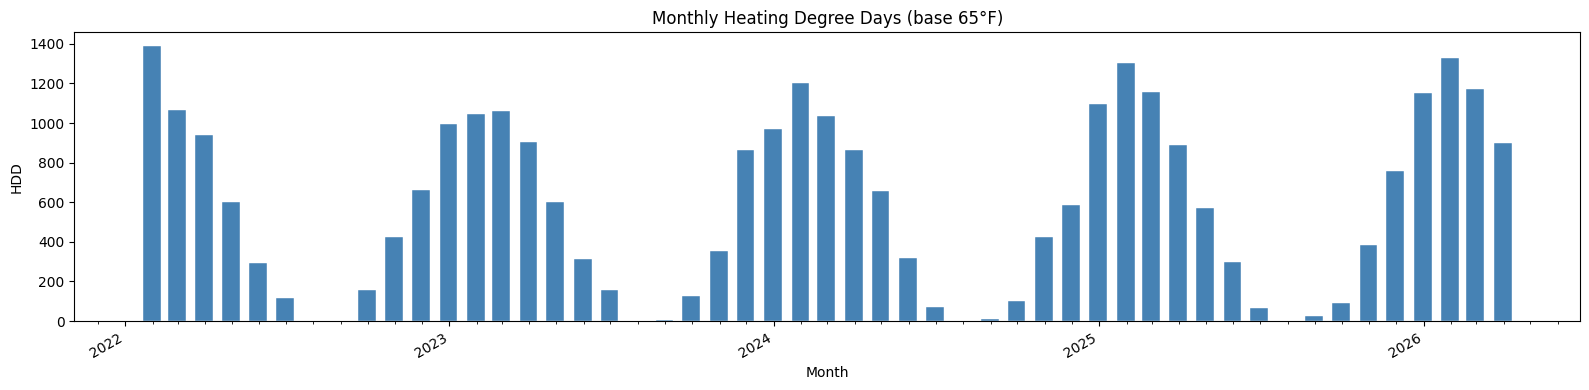

In [17]:
import numpy as np

# Compute daily HDD: sum daily (65 - mean_f) where mean_f < 65
daily_mean_f = df.resample("D", on="time")["temp_f"].mean()
daily_hdd = np.maximum(0, 65 - daily_mean_f)

# Sum daily HDDs into monthly buckets
monthly_hdd = daily_hdd.resample("ME").sum()

# Monthly HDD — annual axis
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(monthly_hdd.index, monthly_hdd.values, width=20, color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_title("Monthly Heating Degree Days (base 65°F)")
ax.set_xlabel("Month")
ax.set_ylabel("HDD")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

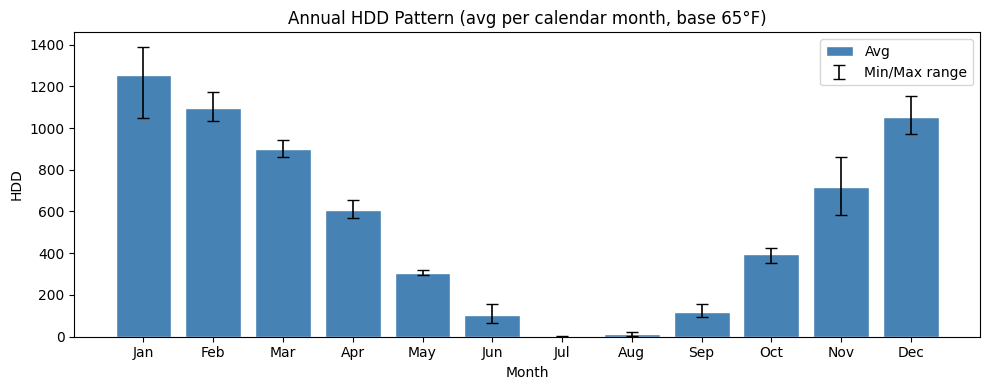

In [18]:
# Annual pattern (avg monthly HDD per calendar month, with min/max range)
monthly_hdd_cal = monthly_hdd.reset_index()
monthly_hdd_cal.columns = ["time", "hdd"]
monthly_hdd_cal["month"] = monthly_hdd_cal["time"].dt.month

by_month = monthly_hdd_cal.groupby("month")["hdd"]
avg = by_month.mean()
low = by_month.min()
high = by_month.max()

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(avg.index, avg.values, color="steelblue", edgecolor="white", label="Avg")
ax.errorbar(avg.index, avg.values,
            yerr=[avg.values - low.values, high.values - avg.values],
            fmt="none", color="black", capsize=4, linewidth=1.2, label="Min/Max range")
ax.set_title("Annual HDD Pattern (avg per calendar month, base 65°F)")
ax.set_xlabel("Month")
ax.set_ylabel("HDD")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend()
plt.tight_layout()
plt.show()

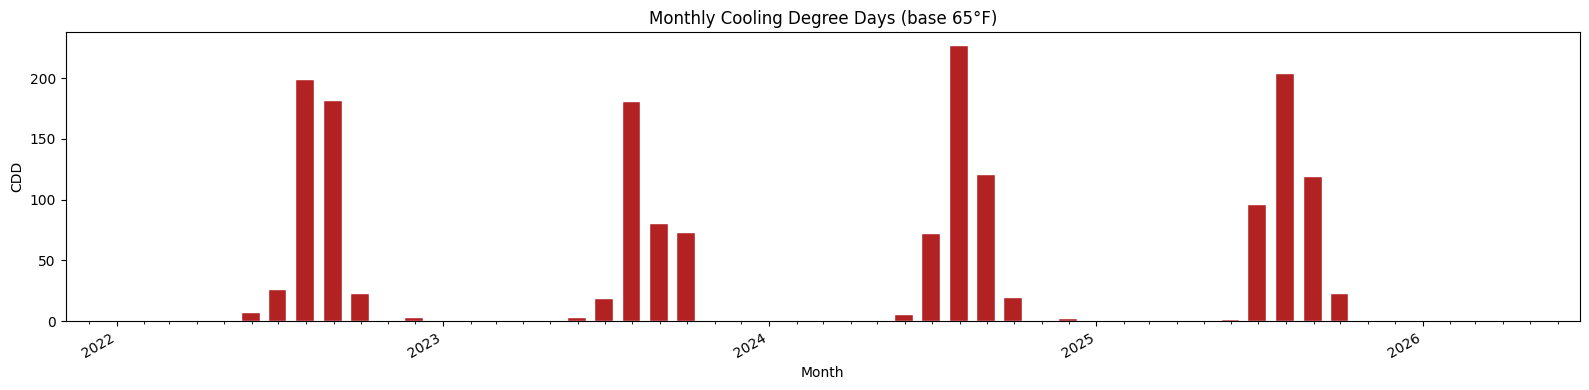

In [ ]:
# Compute monthly Cooling Degree Days (CDD): sum daily (mean_f - 65) where mean_f > 65
daily_cdd = np.maximum(0, daily_mean_f - 65)
monthly_cdd = daily_cdd.resample("ME").sum()

# Monthly CDD — annual axis
fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(monthly_cdd.index, monthly_cdd.values, width=20, color="firebrick", edgecolor="white", linewidth=0.3)
ax.set_title("Monthly Cooling Degree Days (base 65°F)")
ax.set_xlabel("Month")
ax.set_ylabel("CDD")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

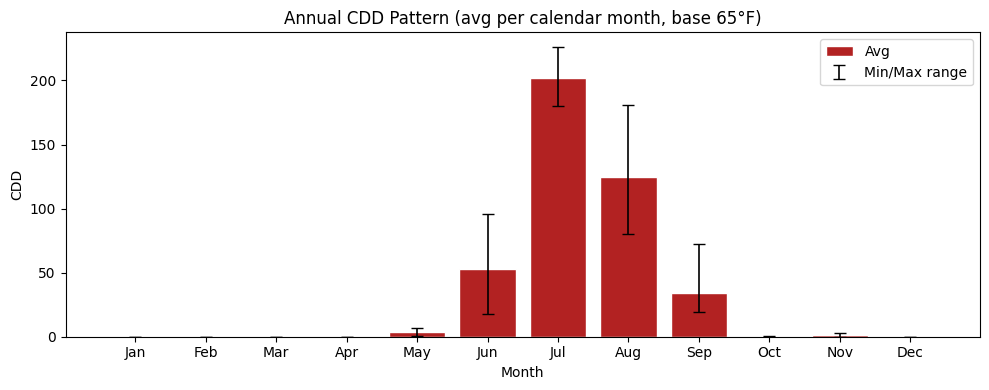

In [20]:
# Annual pattern (avg monthly CDD per calendar month, with min/max range)
monthly_cdd_cal = monthly_cdd.reset_index()
monthly_cdd_cal.columns = ["time", "cdd"]
monthly_cdd_cal["month"] = monthly_cdd_cal["time"].dt.month

by_month = monthly_cdd_cal.groupby("month")["cdd"]
avg = by_month.mean()
low = by_month.min()
high = by_month.max()

month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(avg.index, avg.values, color="firebrick", edgecolor="white", label="Avg")
ax.errorbar(avg.index, avg.values,
            yerr=[avg.values - low.values, high.values - avg.values],
            fmt="none", color="black", capsize=4, linewidth=1.2, label="Min/Max range")
ax.set_title("Annual CDD Pattern (avg per calendar month, base 65°F)")
ax.set_xlabel("Month")
ax.set_ylabel("CDD")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.legend()
plt.tight_layout()
plt.show()